# Ethical Trout Fishing Conditions Assistant
A rough draft for an assistant that uses real-time USGS river data to help anglers think more carefully about river conditions and trout safety in an attempt to conserve the fisheries we love.

## Current scope
- Retrieve recent USGS streamflow, gage height, and water-temperature observations.
- Convert water temperature from celsius to fahrenheit
- Summarize the latest reading and 7-day average for high pressure rivers in Western North Carolina.
- Produce a conservative trout-fishing recommendation using water temperature first and recent streamflow as secondary context.

**Important**:
This is an educational decision-support tool, not a guarantee of fishing conditions or wading safety. Conditions may vary from metrics on the tool - always check local fly shops and online for regulations, closures, weather, access, etc.

## Live USGS Streamflow Data API Integration

This section retrieves real-time streamflow data from the USGS Water Services API. 

The API request specifies:
- JSON formatting
- a specific USGS river monitoring station (03451500) for French Broad River data
- streamflow measurements
- and a recent time window of observations

The returned JSON data is parsed and converted into a pandas dataframe for analysis and visualization.

In [1]:
import requests 
import pandas as pd

#url
url =  "https://waterservices.usgs.gov/nwis/iv/?format=json&sites=03451500&parameterCd=00060&period=P7D"

response = requests.get(url)

# convert json to python object
data = response.json()

time_series = data['value']['timeSeries'][0]['values'][0]['value']

# convert to tabular dataframe for pandas use
river_df = pd.DataFrame(time_series)

# display top of dataframe
river_df.head()


,value,qualifiers,dateTime
0,1630,[P],2026-08-12T13:00:00.000-04:00
1,1630,[P],2026-08-12T13:15:00.000-04:00
2,1640,[P],2026-08-12T13:30:00.000-04:00
3,1640,[P],2026-08-12T13:45:00.000-04:00
4,1640,[P],2026-08-12T14:00:00.000-04:00


In [2]:
len(river_df)

671

In [3]:
# convert from text to float
river_df['value'] = river_df['value'].astype(float)
# convert to dateTime objects
river_df['dateTime'] = pd.to_datetime(river_df['dateTime'])

river_df.head()

,value,qualifiers,dateTime
0,1630.0,[P],2026-08-12 13:00:00-04:00
1,1630.0,[P],2026-08-12 13:15:00-04:00
2,1640.0,[P],2026-08-12 13:30:00-04:00
3,1640.0,[P],2026-08-12 13:45:00-04:00
4,1640.0,[P],2026-08-12 14:00:00-04:00


In [4]:
river_df.describe()

,value
count,671.000000
mean,1223.381520
std,176.093421
min,960.000000
25%,1100.000000
50%,1190.000000
75%,1260.000000
max,1660.000000


In [5]:
river_df = river_df.sort_values('dateTime')

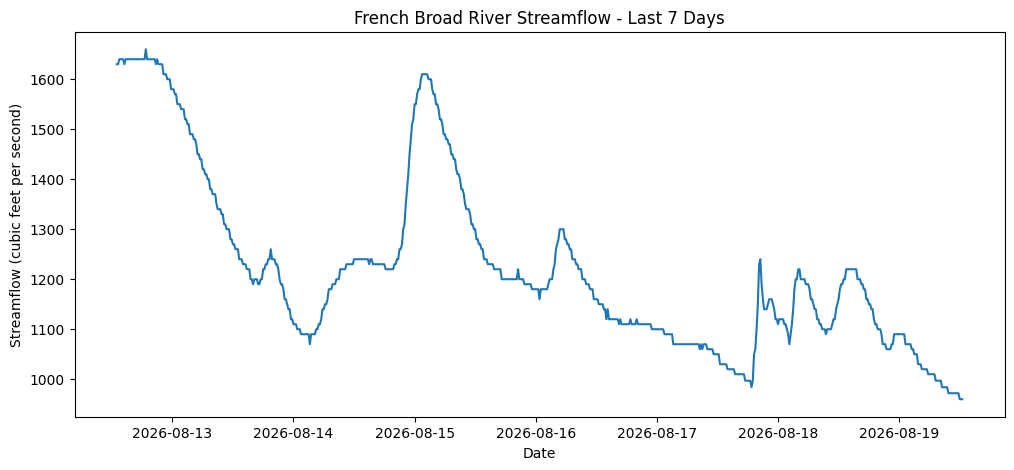

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,5))
plt.plot(river_df['dateTime'], river_df['value'])

plt.title('French Broad River Streamflow - Last 7 Days')
plt.xlabel('Date')
plt.ylabel('Streamflow (cubic feet per second)')
plt.show()

## Live USGS River Height Data API Integration
This section retrieves real-time river height data from the USGS Water Services API.

The API request specifies:

JSON formatting
- a specific USGS river monitoring station (03451500) for French Broad River data
- river height measurements and a recent time window of observations

In [7]:
url_height = "https://waterservices.usgs.gov/nwis/iv/?format=json&sites=03451500&parameterCd=00065&period=P7D"
response_height = requests.get(url_height)
data_height = response_height.json()
time_series_height = data_height['value']['timeSeries'][0]['values'][0]['value']
height_df = pd.DataFrame(time_series_height)

In [8]:
height_df["value"] = height_df['value'].astype(float)

height_df['dateTime'] = pd.to_datetime(height_df['dateTime'])

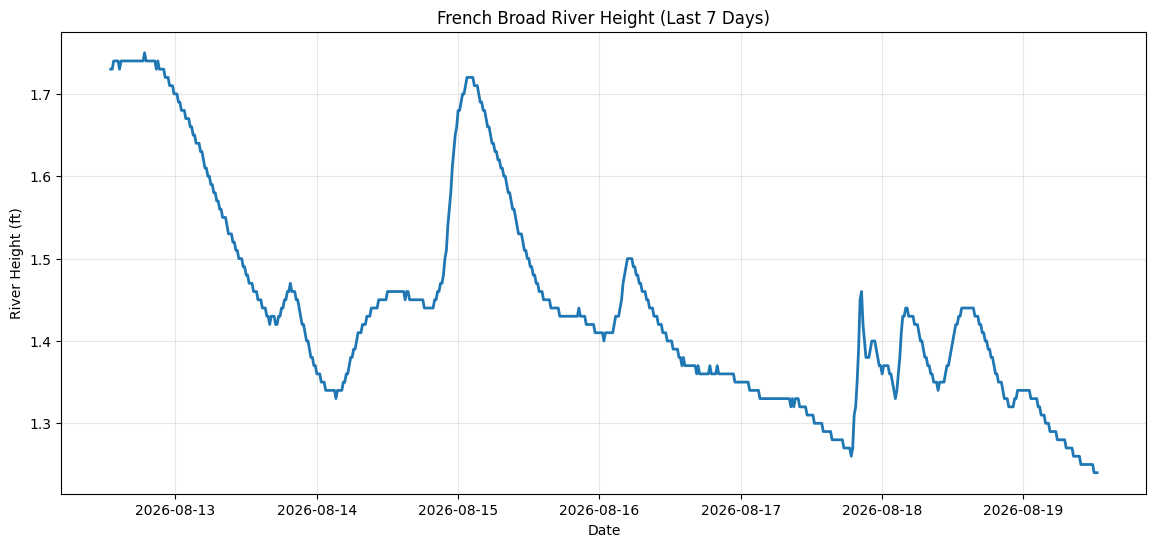

In [9]:
plt.figure(figsize = (14,6))

plt.plot(height_df['dateTime'], height_df['value'],linewidth = 2)

plt.title('French Broad River Height (Last 7 Days)')
plt.xlabel('Date')
plt.ylabel('River Height (ft)')
plt.grid(alpha = 0.3)
plt.show()

## get_usgs function
You can put in a river station, a measurement, and a time period.
It goes to USGS, gets the data, cleans it, and hands you back a pandas DataFrame.

In [10]:
def get_usgs(site, parameter="00060", period="P7D"):
    
    url = (
        f"https://waterservices.usgs.gov/nwis/iv/"
        f"?format=json"
        f"&sites={site}"
        f"&parameterCd={parameter}"
        f"&period={period}"
    )

    response = requests.get(url)
    data = response.json()

    time_series = data["value"]["timeSeries"]

    if len(time_series) == 0:
        print("No data returned.")
        return pd.DataFrame()

    values = time_series[0]["values"][0]["value"]

    if len(values) == 0:
        print("No observations returned.")
        return pd.DataFrame()

    df = pd.DataFrame(values)

    df["value"] = pd.to_numeric(
        df["value"],
        errors="coerce"
    )

    df["dateTime"] = pd.to_datetime(
        df["dateTime"],
        errors="coerce"
    )

    df = df.sort_values("dateTime")

    return df

In [11]:
flow_df = get_usgs(site = '03451500', parameter = '00060')
flow_df.head()

,value,qualifiers,dateTime
0,1630,[P],2026-08-12 13:00:00-04:00
1,1630,[P],2026-08-12 13:15:00-04:00
2,1640,[P],2026-08-12 13:30:00-04:00
3,1640,[P],2026-08-12 13:45:00-04:00
4,1640,[P],2026-08-12 14:00:00-04:00


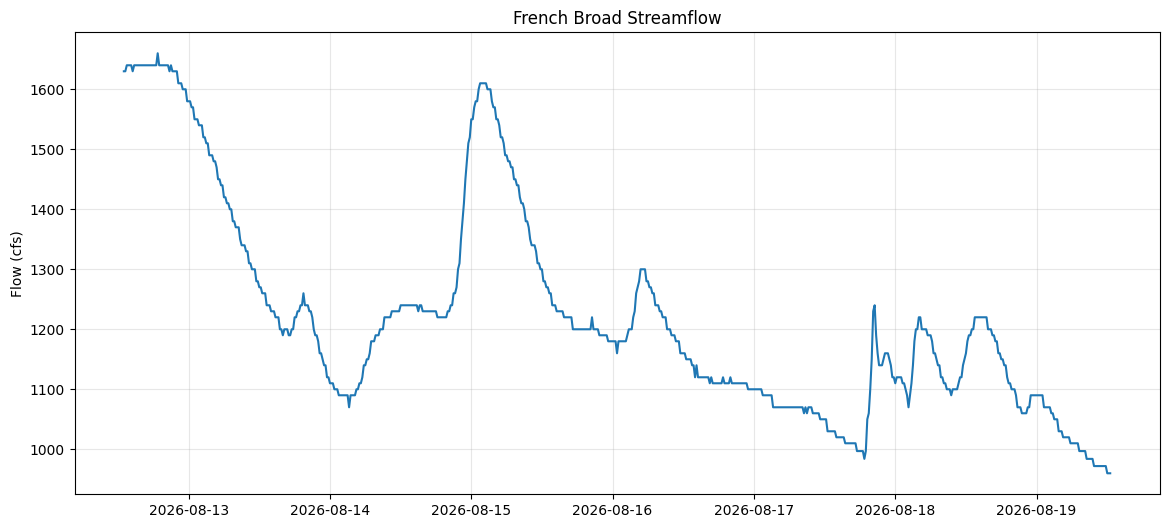

In [12]:
plt.figure(figsize = (14,6))

plt.plot(flow_df['dateTime'], flow_df['value'])
plt.title('French Broad Streamflow')
plt.ylabel('Flow (cfs)')
plt.grid(alpha = .3)
plt.show()

In [13]:
height_df = get_usgs(site = '03451500', parameter = '00065')
height_df.head()

,value,qualifiers,dateTime
0,1.73,[P],2026-08-12 13:00:00-04:00
1,1.73,[P],2026-08-12 13:15:00-04:00
2,1.74,[P],2026-08-12 13:30:00-04:00
3,1.74,[P],2026-08-12 13:45:00-04:00
4,1.74,[P],2026-08-12 14:00:00-04:00


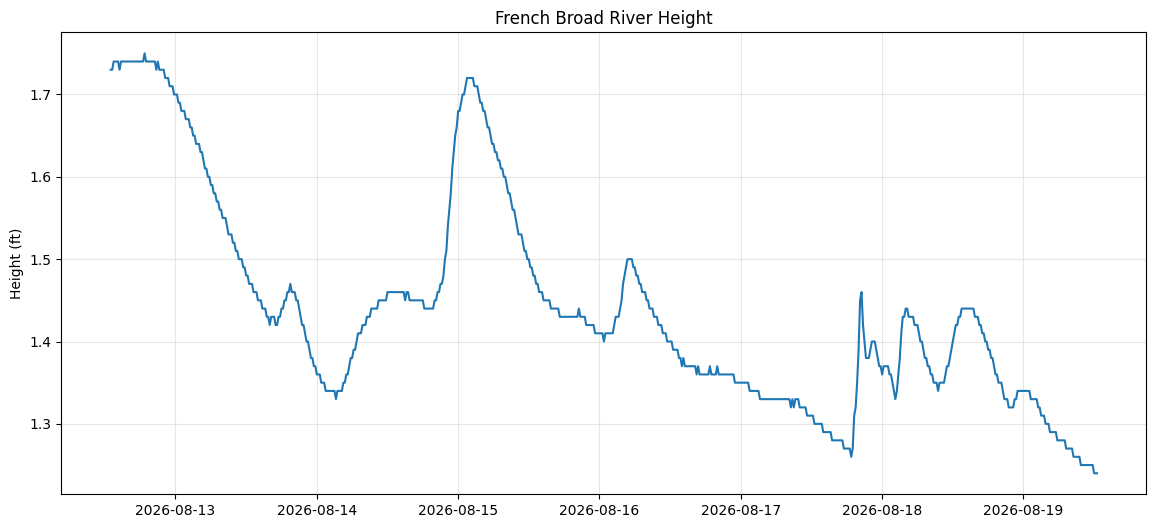

In [14]:
plt.figure(figsize = (14,6))

plt.plot(height_df['dateTime'], height_df['value'])
plt.title('French Broad River Height')
plt.ylabel('Height (ft)')
plt.grid(alpha = .3)
plt.show()

In [15]:
davidson_flow = get_usgs(site="03441000", parameter="00060")
davidson_flow.head()

,value,qualifiers,dateTime
0,57.9,[P],2026-08-12 13:00:00-04:00
1,57.9,[P],2026-08-12 13:15:00-04:00
2,57.9,[P],2026-08-12 13:30:00-04:00
3,57.9,[P],2026-08-12 13:45:00-04:00
4,56.3,[P],2026-08-12 14:00:00-04:00


In [16]:
davidson_height = get_usgs(site="03441000", parameter="00065")
davidson_height.head()

,value,qualifiers,dateTime
0,0.72,[P],2026-08-12 13:00:00-04:00
1,0.72,[P],2026-08-12 13:15:00-04:00
2,0.72,[P],2026-08-12 13:30:00-04:00
3,0.72,[P],2026-08-12 13:45:00-04:00
4,0.71,[P],2026-08-12 14:00:00-04:00


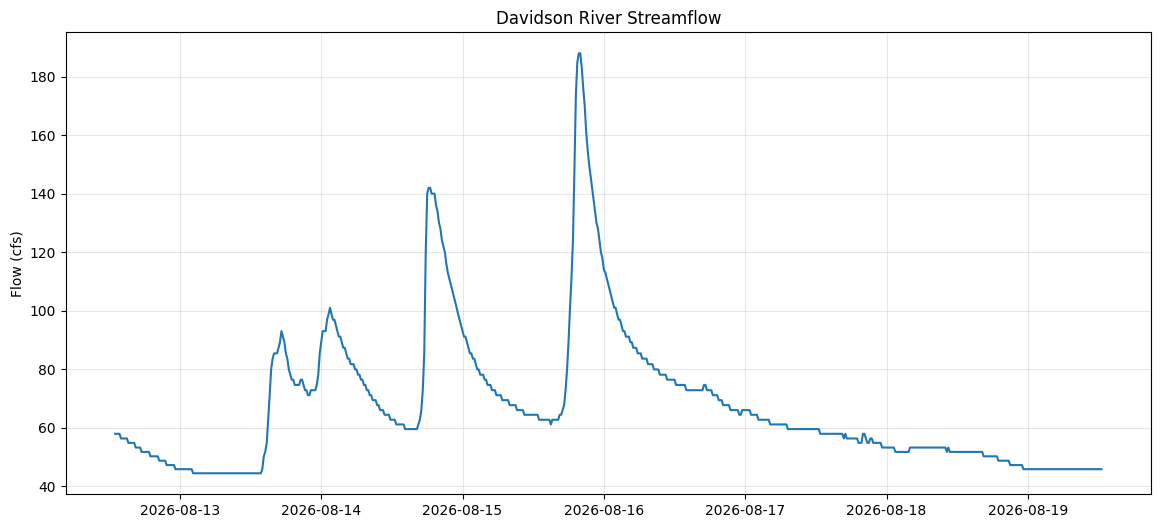

In [17]:
plt.figure(figsize = (14,6))

plt.plot(davidson_flow['dateTime'], davidson_flow['value'])
plt.title('Davidson River Streamflow')
plt.ylabel('Flow (cfs)')
plt.grid(alpha = .3)
plt.show()

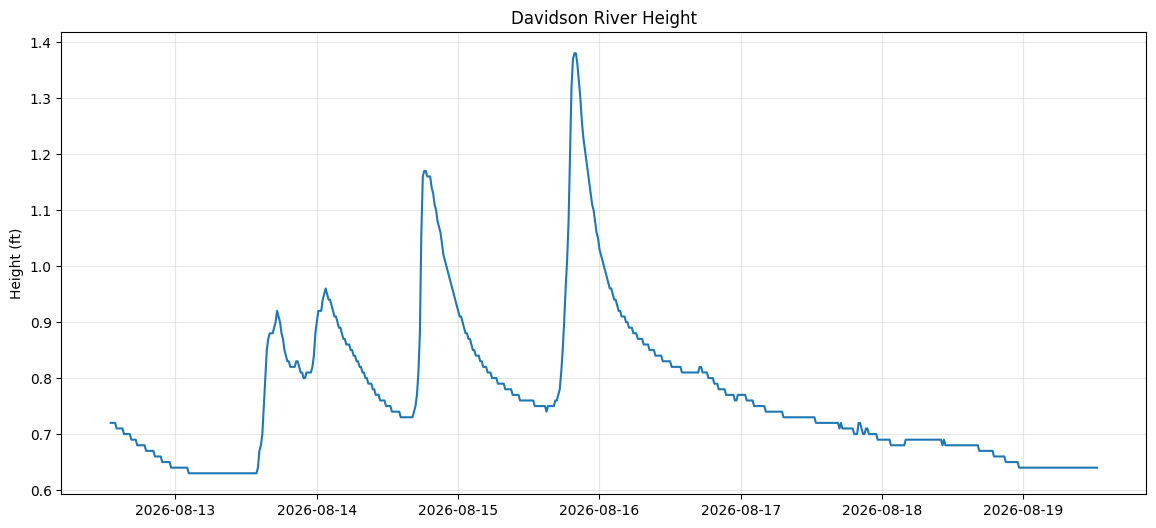

In [18]:
plt.figure(figsize = (14,6))

plt.plot(davidson_height['dateTime'], davidson_height['value'])
plt.title('Davidson River Height')
plt.ylabel('Height (ft)')
plt.grid(alpha = .3)
plt.show()

In [64]:
stations = {
    "French Broad River": "03451500",
    "Davidson River": "03441000",
    "Mills River": "03446000",
    "Cataloochee Creek": "03460000",
    "Oconaluftee River": "03512000"
}

parameters = {
    "Streamflow": {
        "code": "00060",
        "unit": "cfs"
    },
    "Gage Height": {
        "code": "00065",
        "unit": "ft"
    },
    "Water Temperature": {
        "code": "00010",
        "unit": "°F"
    }
}

In [65]:
station_data = {}

for river_name, site_id in stations.items():
    station_data[river_name] = {}

    for measurement_name, parameter_info in parameters.items():

        df = get_usgs(
            site=site_id,
            parameter=parameter_info["code"],
            period="P7D"
        )

        if measurement_name == "Water Temperature" and not df.empty:
            df["value"] = (df["value"] * 9 / 5) + 32

        station_data[river_name][measurement_name] = df

        print(
            river_name,
            measurement_name,
            len(df),
            "readings"
        )

French Broad River Streamflow 670 readings
French Broad River Gage Height 670 readings
French Broad River Water Temperature 670 readings
Davidson River Streamflow 670 readings
Davidson River Gage Height 670 readings
Davidson River Water Temperature 670 readings
Mills River Streamflow 670 readings
Mills River Gage Height 670 readings
Mills River Water Temperature 670 readings
Cataloochee Creek Streamflow 670 readings
Cataloochee Creek Gage Height 670 readings
Cataloochee Creek Water Temperature 670 readings
Oconaluftee River Streamflow 668 readings
Oconaluftee River Gage Height 668 readings
Oconaluftee River Water Temperature 668 readings


In [66]:
summary_rows = []

for river_name, measurements in station_data.items():
    for measurement_name, df in measurements.items():

        if df.empty:
            continue

        latest_value = df["value"].iloc[-1]
        recent_average = df["value"].mean()

        percent_difference = (
            (latest_value - recent_average)
            / recent_average
        ) * 100

        summary_rows.append({
            "River": river_name,
            "Measurement": measurement_name,
            "Latest Value": latest_value,
            "7-Day Average": recent_average,
            "Difference from Average (%)": percent_difference,
            "Last Updated": df["dateTime"].iloc[-1]
        })

current_conditions = pd.DataFrame(summary_rows)

current_conditions

,River,Measurement,Latest Value,7-Day Average,Difference from Average (%),Last Updated
0,French Broad River,Streamflow,947.00,1206.429851,-21.503932,2026-08-19 16:30:00-04:00
1,French Broad River,Gage Height,1.23,1.429552,-13.959073,2026-08-19 16:30:00-04:00
2,French Broad River,Water Temperature,81.86,78.171881,4.717962,2026-08-19 16:30:00-04:00
3,Davidson River,Streamflow,45.80,67.246866,-31.892736,2026-08-19 16:30:00-04:00
4,Davidson River,Gage Height,0.64,0.769388,-16.817009,2026-08-19 16:30:00-04:00
5,Davidson River,Water Temperature,74.66,70.796716,5.456868,2026-08-19 16:30:00-04:00
6,Mills River,Streamflow,75.80,100.755522,-24.768392,2026-08-19 16:30:00-04:00
7,Mills River,Gage Height,1.87,1.999164,-6.460909,2026-08-19 16:30:00-04:00
8,Mills River,Water Temperature,76.28,71.162358,7.191501,2026-08-19 16:30:00-04:00
9,Cataloochee Creek,Streamflow,97.10,108.046866,-10.131590,2026-08-19 16:30:00-04:00


In [67]:
summary_rows = []

for river_name, measurements in station_data.items():
    for measurement_name, df in measurements.items():
        if df.empty:
            continue
        latest_value = df['value'].iloc[-1]
        recent_average = df['value'].mean()

        percent_diff = ((latest_value - recent_average) / recent_average) * 100

        def classify_condition(percent_diff):
            if percent_diff >= 30:
                return "Much Higher Than Normal"
            elif percent_diff >= 10:
                return "Above Average"
            elif percent_diff <= -30:
                return "Much Lower Than Average"
            elif percent_diff <= -10:
                return "Below Average"
            else:
                return "Near Average"

        summary_rows.append({
            "River": river_name,
            "Measurement": measurement_name,
            "Latest Value": latest_value,
            "7-Day Average": recent_average,
            "Difference from Average (%)": percent_diff,
            "Last Updated": df['dateTime'].iloc[-1],
            "Condition": classify_condition(percent_diff)
        })

current_conditions = pd.DataFrame(summary_rows)
current_conditions
            

,River,Measurement,Latest Value,7-Day Average,Difference from Average (%),Last Updated,Condition
0,French Broad River,Streamflow,947.00,1206.429851,-21.503932,2026-08-19 16:30:00-04:00,Below Average
1,French Broad River,Gage Height,1.23,1.429552,-13.959073,2026-08-19 16:30:00-04:00,Below Average
2,French Broad River,Water Temperature,81.86,78.171881,4.717962,2026-08-19 16:30:00-04:00,Near Average
3,Davidson River,Streamflow,45.80,67.246866,-31.892736,2026-08-19 16:30:00-04:00,Much Lower Than Average
4,Davidson River,Gage Height,0.64,0.769388,-16.817009,2026-08-19 16:30:00-04:00,Below Average
5,Davidson River,Water Temperature,74.66,70.796716,5.456868,2026-08-19 16:30:00-04:00,Near Average
6,Mills River,Streamflow,75.80,100.755522,-24.768392,2026-08-19 16:30:00-04:00,Below Average
7,Mills River,Gage Height,1.87,1.999164,-6.460909,2026-08-19 16:30:00-04:00,Near Average
8,Mills River,Water Temperature,76.28,71.162358,7.191501,2026-08-19 16:30:00-04:00,Near Average
9,Cataloochee Creek,Streamflow,97.10,108.046866,-10.131590,2026-08-19 16:30:00-04:00,Below Average


In [94]:
def ethical_fishing(temperature, flow_percent_difference):
    if temperature >= 68:
        return (
            "Use Extreme Caution",
            "Water is greater 68°F, and trout may already be experiencing heat stress.",
            "Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet."
        )
    elif temperature >= 65:
        return (
            "Use Extreme Caution",
            "Water temperature is between 65°F and 68°F.",
            "Consider not targeting trout and minimize handling if you do fish."
        )
    elif flow_percent_difference <= -30:
        return (
            "Caution - streamflow is substaintially below 7-day average.",
            "Low water can reduce habitat and concentrate fish, possibly causing stress.",
            "Consider fishing in another body with more water and better flow."
        )
    elif flow_percent_difference >= 50:
        return (
            "Check Access and Wading Safety",
            "Streamflow is above recent 7-day average.",
            "Do not treat this tool as a wading-safety guarantee. Check local warnings and observe river."
        )
    else:
        return (
            "Lower Apparent Stress",
            "Temperature is below 65°F and flow is not far outside its recent range.",
            "Continue to check local regulations and handle trout responsibly."
        )
 
                
            

In [95]:
fishing_conditions = current_conditions.pivot(
    index="River",
    columns="Measurement",
    values="Latest Value"
).reset_index()

fishing_conditions.columns.name = None

fishing_conditions

,River,Gage Height,Streamflow,Water Temperature
0,Cataloochee Creek,2.51,97.1,66.38
1,Davidson River,0.64,45.8,74.66
2,French Broad River,1.23,947.0,81.86
3,Mills River,1.87,75.8,76.28
4,Oconaluftee River,1.59,327.0,73.04


In [96]:
flow_context = current_conditions[
    current_conditions["Measurement"] == "Streamflow"
][
    ["River", "Difference from Average (%)"]
]

flow_context

,River,Difference from Average (%)
0,French Broad River,-21.503932
3,Davidson River,-31.892736
6,Mills River,-24.768392
9,Cataloochee Creek,-10.131590
12,Oconaluftee River,-12.754026


In [97]:
flow_context = flow_context.rename(
    columns={
        "Difference from Average (%)": "Flow Difference (%)"
    }
)

In [98]:
# fishing_conditions = what the river is doing
fishing_conditions = fishing_conditions.merge(
    flow_context,
    on="River",
    how="left"
)

fishing_conditions

,River,Gage Height,Streamflow,Water Temperature,Flow Difference (%)
0,Cataloochee Creek,2.51,97.1,66.38,-10.131590
1,Davidson River,0.64,45.8,74.66,-31.892736
2,French Broad River,1.23,947.0,81.86,-21.503932
3,Mills River,1.87,75.8,76.28,-24.768392
4,Oconaluftee River,1.59,327.0,73.04,-12.754026


In [99]:
recommendations = []

In [100]:
# loop for adding temperature, flow difference, status, reason, and guidance
for index, row in fishing_conditions.iterrows():
    status, reason, guidance = ethical_fishing(
        temperature=row["Water Temperature"],
        flow_percent_difference=row["Flow Difference (%)"]
    )

    recommendations.append({
        "Fishing Status": status,
        "Reason": reason,
        "Guidance": guidance
    })

In [101]:
# recommendation_df = what fishing_conditions observations means is recommended for ethical trout fishing.
recommendation_df = pd.DataFrame(recommendations)
recommendation_df

,Fishing Status,Reason,Guidance
0,Use Extreme Caution,Water temperature is between 65°F and 68°F.,Consider not targeting trout and minimize hand...
1,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
2,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
3,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
4,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."


In [102]:
final_conditions = pd.concat([fishing_conditions.reset_index(drop = True), recommendation_df.reset_index(drop=True)], axis = 1)
final_conditions

,River,Gage Height,Streamflow,Water Temperature,Flow Difference (%),Fishing Status,Reason,Guidance
0,Cataloochee Creek,2.51,97.1,66.38,-10.131590,Use Extreme Caution,Water temperature is between 65°F and 68°F.,Consider not targeting trout and minimize hand...
1,Davidson River,0.64,45.8,74.66,-31.892736,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
2,French Broad River,1.23,947.0,81.86,-21.503932,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
3,Mills River,1.87,75.8,76.28,-24.768392,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."
4,Oconaluftee River,1.59,327.0,73.04,-12.754026,Use Extreme Caution,"Water is greater 68°F, and trout may already b...","Consider not targeting trout. If you do fish, ..."


In [103]:
def build_river_reports(final_conditions):
    reports = []
    for index, row in final_conditions.iterrows():
        report = {
            "River": row["River"],
            "Water Temperature (°F)": round(row["Water Temperature"],1),
            "Streamflow (cfs)": round(row["Streamflow"], 1),
            "Gage Height (ft)": round(row["Gage Height"], 2),
            "Flow Difference (%)": round(row["Flow Difference (%)"], 1),
            "Fishing Status": row["Fishing Status"],
            "Reason": row["Reason"],
            "Guidance": row["Guidance"]
        }

        reports.append(report)
    return reports
                                      
                                            

In [104]:
river_reports = build_river_reports(final_conditions)
river_reports

[{'River': 'Cataloochee Creek',
  'Water Temperature (°F)': 66.4,
  'Streamflow (cfs)': 97.1,
  'Gage Height (ft)': 2.51,
  'Flow Difference (%)': -10.1,
  'Fishing Status': 'Use Extreme Caution',
  'Reason': 'Water temperature is between 65°F and 68°F.',
  'Guidance': 'Consider not targeting trout and minimize handling if you do fish.'},
 {'River': 'Davidson River',
  'Water Temperature (°F)': 74.7,
  'Streamflow (cfs)': 45.8,
  'Gage Height (ft)': 0.64,
  'Flow Difference (%)': -31.9,
  'Fishing Status': 'Use Extreme Caution',
  'Reason': 'Water is greater 68°F, and trout may already be experiencing heat stress.',
  'Guidance': 'Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.'},
 {'River': 'French Broad River',
  'Water Temperature (°F)': 81.9,
  'Streamflow (cfs)': 947.0,
  'Gage Height (ft)': 1.23,
  'Flow Difference (%)': -21.5,
  'Fishing Status': 'Use Extreme Caution',
  'Reason': 'Water is greater 68

In [105]:
def get_river_report(river_name, river_reports):

    for report in river_reports:
        if report["River"] == river_name:
            return report
    return None

In [106]:
davidson_report = get_river_report("Davidson River", river_reports)
davidson_report

{'River': 'Davidson River',
 'Water Temperature (°F)': 74.7,
 'Streamflow (cfs)': 45.8,
 'Gage Height (ft)': 0.64,
 'Flow Difference (%)': -31.9,
 'Fishing Status': 'Use Extreme Caution',
 'Reason': 'Water is greater 68°F, and trout may already be experiencing heat stress.',
 'Guidance': 'Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.'}

In [107]:
french_broad_report = get_river_report("French Broad River", river_reports)
french_broad_report

{'River': 'French Broad River',
 'Water Temperature (°F)': 81.9,
 'Streamflow (cfs)': 947.0,
 'Gage Height (ft)': 1.23,
 'Flow Difference (%)': -21.5,
 'Fishing Status': 'Use Extreme Caution',
 'Reason': 'Water is greater 68°F, and trout may already be experiencing heat stress.',
 'Guidance': 'Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.'}

In [108]:
mills_report = get_river_report("Mills River", river_reports)
mills_report

{'River': 'Mills River',
 'Water Temperature (°F)': 76.3,
 'Streamflow (cfs)': 75.8,
 'Gage Height (ft)': 1.87,
 'Flow Difference (%)': -24.8,
 'Fishing Status': 'Use Extreme Caution',
 'Reason': 'Water is greater 68°F, and trout may already be experiencing heat stress.',
 'Guidance': 'Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.'}

In [109]:
cataloochee_report = get_river_report("Cataloochee Creek", river_reports)
cataloochee_report

{'River': 'Cataloochee Creek',
 'Water Temperature (°F)': 66.4,
 'Streamflow (cfs)': 97.1,
 'Gage Height (ft)': 2.51,
 'Flow Difference (%)': -10.1,
 'Fishing Status': 'Use Extreme Caution',
 'Reason': 'Water temperature is between 65°F and 68°F.',
 'Guidance': 'Consider not targeting trout and minimize handling if you do fish.'}

In [110]:
luftee_report = get_river_report("Oconaluftee River", river_reports)
luftee_report

{'River': 'Oconaluftee River',
 'Water Temperature (°F)': 73.0,
 'Streamflow (cfs)': 327.0,
 'Gage Height (ft)': 1.59,
 'Flow Difference (%)': -12.8,
 'Fishing Status': 'Use Extreme Caution',
 'Reason': 'Water is greater 68°F, and trout may already be experiencing heat stress.',
 'Guidance': 'Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.'}

In [111]:
def print_river_report(report):
    if report is None:
        print("River not found.")
        return

    print(f"River: {report['River']}")
    print(f"Water Temperature: {report['Water Temperature (°F)']} °F")
    print(f"Streamflow: {report['Streamflow (cfs)']} cfs")
    print(f"Gage Height: {report['Gage Height (ft)']} ft")
    print(f"Flow Difference: {report['Flow Difference (%)']}%")
    print()
    print(f"Fishing Status: {report['Fishing Status']}")
    print(f"Reason: {report['Reason']}")
    print(f"Guidance: {report['Guidance']}")

In [112]:
print_river_report(davidson_report)

River: Davidson River
Water Temperature: 74.7 °F
Streamflow: 45.8 cfs
Gage Height: 0.64 ft
Flow Difference: -31.9%

Fishing Status: Use Extreme Caution
Reason: Water is greater 68°F, and trout may already be experiencing heat stress.
Guidance: Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.


In [113]:
print_river_report(french_broad_report)

River: French Broad River
Water Temperature: 81.9 °F
Streamflow: 947.0 cfs
Gage Height: 1.23 ft
Flow Difference: -21.5%

Fishing Status: Use Extreme Caution
Reason: Water is greater 68°F, and trout may already be experiencing heat stress.
Guidance: Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.


In [114]:
print_river_report(mills_report)

River: Mills River
Water Temperature: 76.3 °F
Streamflow: 75.8 cfs
Gage Height: 1.87 ft
Flow Difference: -24.8%

Fishing Status: Use Extreme Caution
Reason: Water is greater 68°F, and trout may already be experiencing heat stress.
Guidance: Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.


In [115]:
print_river_report(cataloochee_report)

River: Cataloochee Creek
Water Temperature: 66.4 °F
Streamflow: 97.1 cfs
Gage Height: 2.51 ft
Flow Difference: -10.1%

Fishing Status: Use Extreme Caution
Reason: Water temperature is between 65°F and 68°F.
Guidance: Consider not targeting trout and minimize handling if you do fish.


In [116]:
print_river_report(luftee_report)

River: Oconaluftee River
Water Temperature: 73.0 °F
Streamflow: 327.0 cfs
Gage Height: 1.59 ft
Flow Difference: -12.8%

Fishing Status: Use Extreme Caution
Reason: Water is greater 68°F, and trout may already be experiencing heat stress.
Guidance: Consider not targeting trout. If you do fish, land and release fish quickly, minimize handling and photos, and keep trout wet.
